# Yield-Curve Construction and Interpolation

## Objective

This notebook constructs two term structures from the same set of observed
continuously compounded zero rates:

1. linear interpolation of zero rates;
2. linear interpolation of discount factors.

The resulting zero, discount, and instantaneous forward curves are compared.
Later notebooks use both term structures to examine whether interpolation
choice materially affects bond and swap valuation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

In [2]:
market_data = pd.DataFrame(
    {
        "maturity": [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0],
        "zero_rate": [0.0420, 0.0435, 0.0445, 0.0438, 0.0415, 0.0400, 0.0390],
    }
)

market_data["discount_factor"] = np.exp(
    -market_data["zero_rate"] * market_data["maturity"]
)

market_data

,maturity,zero_rate,discount_factor
0,0.5,0.0420,0.979219
1,1.0,0.0435,0.957433
2,2.0,0.0445,0.914846
3,3.0,0.0438,0.876867
4,5.0,0.0415,0.812613
5,7.0,0.0400,0.755784
6,10.0,0.0390,0.677057


The inputs are illustrative rather than current market observations. Their
non-flat shape makes differences between interpolation approaches easier to
examine while keeping the experiment controlled.

In [3]:
curve_maturities = np.linspace(
    market_data["maturity"].min(),
    market_data["maturity"].max(),
    500,
)

## Method 1: Linear interpolation of zero rates

Continuously compounded zero rates are interpolated directly. Discount factors
are then obtained from

\[
P_z(0,T)=\exp[-z(T)T].
\]

In [4]:
zero_rate_interpolator = interp1d(
    market_data["maturity"],
    market_data["zero_rate"],
    kind="linear",
)

zero_rates_from_zero_interpolation = zero_rate_interpolator(
    curve_maturities
)

discount_factors_from_zero_interpolation = np.exp(
    -zero_rates_from_zero_interpolation * curve_maturities
)

## Method 2: Linear interpolation of discount factors

Observed discount factors are interpolated directly. The corresponding
continuously compounded zero rates are recovered from

\[
z_P(T)=-\frac{\log P(0,T)}{T}.
\]

In [5]:
discount_factor_interpolator = interp1d(
    market_data["maturity"],
    market_data["discount_factor"],
    kind="linear",
)

discount_factors_from_discount_interpolation = (
    discount_factor_interpolator(curve_maturities)
)

zero_rates_from_discount_interpolation = (
    -np.log(discount_factors_from_discount_interpolation)
    / curve_maturities
)

In [6]:
assert np.allclose(
    zero_rate_interpolator(market_data["maturity"]),
    market_data["zero_rate"],
)

assert np.allclose(
    discount_factor_interpolator(market_data["maturity"]),
    market_data["discount_factor"],
)

assert np.all(
    discount_factors_from_zero_interpolation > 0
)

assert np.all(
    discount_factors_from_discount_interpolation > 0
)

print("Validation checks passed.")

Validation checks passed.


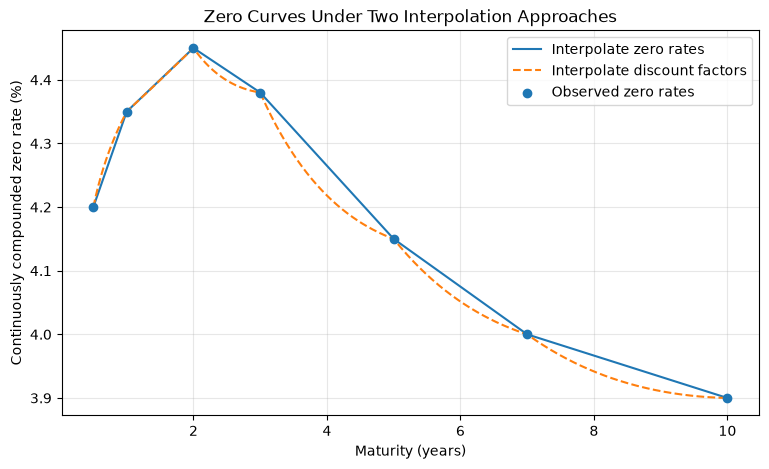

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    curve_maturities,
    100 * zero_rates_from_zero_interpolation,
    label="Interpolate zero rates",
)

plt.plot(
    curve_maturities,
    100 * zero_rates_from_discount_interpolation,
    linestyle="--",
    label="Interpolate discount factors",
)

plt.scatter(
    market_data["maturity"],
    100 * market_data["zero_rate"],
    label="Observed zero rates",
    zorder=3,
)

plt.xlabel("Maturity (years)")
plt.ylabel("Continuously compounded zero rate (%)")
plt.title("Zero Curves Under Two Interpolation Approaches")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

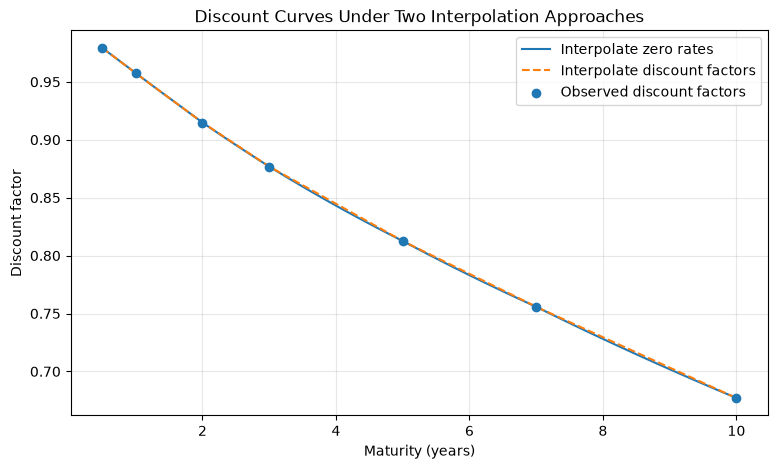

In [8]:
plt.figure(figsize=(9, 5))

plt.plot(
    curve_maturities,
    discount_factors_from_zero_interpolation,
    label="Interpolate zero rates",
)

plt.plot(
    curve_maturities,
    discount_factors_from_discount_interpolation,
    linestyle="--",
    label="Interpolate discount factors",
)

plt.scatter(
    market_data["maturity"],
    market_data["discount_factor"],
    label="Observed discount factors",
    zorder=3,
)

plt.xlabel("Maturity (years)")
plt.ylabel("Discount factor")
plt.title("Discount Curves Under Two Interpolation Approaches")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
comparison = pd.DataFrame(
    {
        "maturity": curve_maturities,
        "zero_rate_interpolation": zero_rates_from_zero_interpolation,
        "discount_factor_interpolation": (
            zero_rates_from_discount_interpolation
        ),
        "discount_factor_from_zero_rates": (
            discount_factors_from_zero_interpolation
        ),
        "interpolated_discount_factor": (
            discount_factors_from_discount_interpolation
        ),
    }
)

comparison["zero_rate_difference_bp"] = (
    comparison["discount_factor_interpolation"]
    - comparison["zero_rate_interpolation"]
) * 10_000

comparison["discount_factor_difference"] = (
    comparison["interpolated_discount_factor"]
    - comparison["discount_factor_from_zero_rates"]
)

comparison.head()

,maturity,zero_rate_interpolation,discount_factor_interpolation,discount_factor_from_zero_rates,interpolated_discount_factor,zero_rate_difference_bp,discount_factor_difference
0,0.500000,0.042000,0.042000,0.979219,0.979219,5.551115e-13,0.000000
1,0.519038,0.042057,0.042092,0.978407,0.978389,3.518558e-01,-0.000018
2,0.538076,0.042114,0.042179,0.977594,0.977560,6.517571e-01,-0.000034
3,0.557114,0.042171,0.042262,0.976780,0.976730,9.050522e-01,-0.000049
4,0.576152,0.042228,0.042340,0.975964,0.975901,1.116382e+00,-0.000063


In [10]:
maximum_zero_rate_difference_bp = (
    comparison["zero_rate_difference_bp"].abs().max()
)

maximum_discount_factor_difference = (
    comparison["discount_factor_difference"].abs().max()
)

print(
    "Maximum absolute zero-rate difference:",
    f"{maximum_zero_rate_difference_bp:.4f} bp",
)

print(
    "Maximum absolute discount-factor difference:",
    f"{maximum_discount_factor_difference:.8f}",
)

Maximum absolute zero-rate difference: 4.7538 bp
Maximum absolute discount-factor difference: 0.00161890


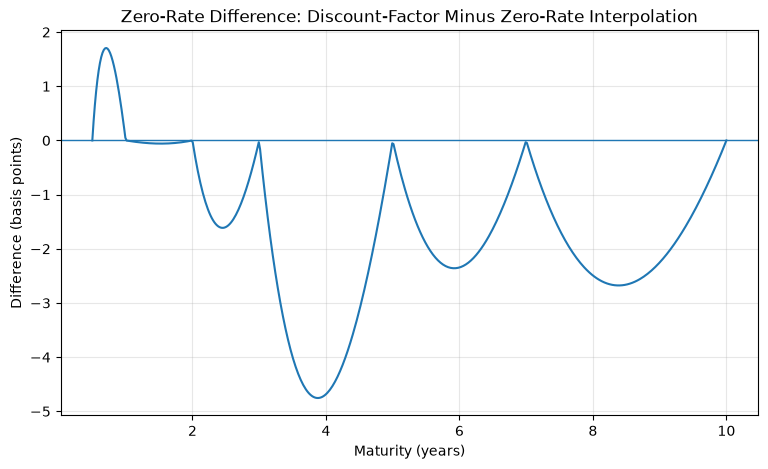

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    comparison["maturity"],
    comparison["zero_rate_difference_bp"],
)

plt.axhline(0, linewidth=1)

plt.xlabel("Maturity (years)")
plt.ylabel("Difference (basis points)")
plt.title(
    "Zero-Rate Difference: Discount-Factor Minus Zero-Rate Interpolation"
)
plt.grid(alpha=0.3)
plt.show()

## Initial Findings

Both interpolation approaches reproduce the observed market data exactly at
the quoted maturities. However, they impose linearity on different quantities,
resulting in distinct zero-rate and discount curves between market observations.

Although the differences in the interpolated curves are relatively small, they
may become more pronounced when examining implied forward rates or valuing
longer-dated fixed-income instruments. The next stage of this project
investigates whether these differences propagate into bond valuation and
interest-rate risk measures.